In [1]:
import numpy as np
import pandas as pd

In [2]:
voltage_normal = pd.read_csv('./data/voltage_data.csv')
voltage_outage = pd.read_csv('./data/voltage_data_outage.csv')

In [3]:
voltage_normal.shape, voltage_outage.shape

((10000, 20), (10000, 20))

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# Combine the data and create labels
X = pd.concat([voltage_normal, voltage_outage])
y = np.concatenate([np.zeros(len(voltage_normal)), np.ones(len(voltage_outage))])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20)

# Standardize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create and train the logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy}')
print('Classification Report:')
print(report)

Accuracy: 0.97575
Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      0.97      0.98      1994
         1.0       0.98      0.98      0.98      2006

    accuracy                           0.98      4000
   macro avg       0.98      0.98      0.98      4000
weighted avg       0.98      0.98      0.98      4000



/tmp/ipykernel_691107/2888996471.py:27: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, edgecolors='k', marker='x', label='Test')


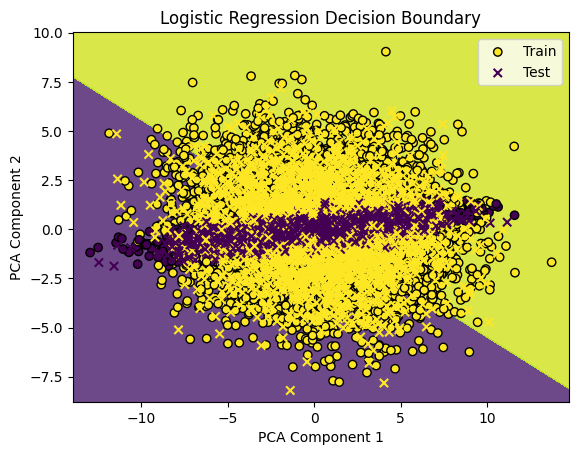

In [5]:
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

# Reduce the data to two dimensions using PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Train the logistic regression model on the reduced data
model_pca = LogisticRegression()
model_pca.fit(X_train_pca, y_train)

# Create a mesh to plot the decision boundary
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

# Predict the function value for the whole grid
Z = model_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.contourf(xx, yy, Z, alpha=0.8)
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, edgecolors='k', marker='o', label='Train')
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, edgecolors='k', marker='x', label='Test')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.title('Logistic Regression Decision Boundary')
plt.show()

In [6]:
# Get the coefficients of the logistic regression model
coefficients = model.coef_[0]

# Create a dataframe to display the feature importance››
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': coefficients})

# Sort the dataframe by importance
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

print(feature_importance)

   Feature  Importance
6    Bus_7    3.994383
17  Bus_18    3.365577
0    Bus_1    3.189223
9   Bus_10    1.504628
19  Bus_20    1.417058
16  Bus_17    0.449478
2    Bus_3    0.376772
15  Bus_16    0.227966
12  Bus_13    0.088494
8    Bus_9   -0.079900
4    Bus_5   -0.116087
13  Bus_14   -0.258484
7    Bus_8   -0.350085
1    Bus_2   -0.393680
11  Bus_12   -1.001835
3    Bus_4   -1.429690
5    Bus_6   -1.762192
10  Bus_11   -1.788083
18  Bus_19   -3.214265
14  Bus_15   -3.644806
